<a href="https://colab.research.google.com/github/Arshdeep-A/R-Analytics-and-Visualisation/blob/main/NorthStar_R_Service_and_Incident_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Install and Load Required Libraries

In [1]:
install.packages("ggplot2")

install.packages("dplyr")

install.packages("corrplot")

library(ggplot2)

library(dplyr)

library(corrplot)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



Step 2 — Import Datasets from GitHub

In [2]:
complaints <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/complaints.csv"
)

customers <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/customers.csv"
)

orders <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/orders.csv"
)

deliveries <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/deliveries.csv"
)

drivers <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/drivers.csv"
)

incidents <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/incidents.csv"
)

vehicles <- read.csv(
"https://raw.githubusercontent.com/Arshdeep-A/Dataset_Northstar/refs/heads/main/vehicles.csv"
)

Step 3 — Dataset Exploration

In [3]:
head(complaints)

head(drivers)

head(incidents)

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
1,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
2,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
3,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
4,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
5,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
6,CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<int>
1,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
2,D002,Central,FullTime,4,42.4,3.94,Evening,1
3,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
4,D004,Airport,PartTime,13,88.9,4.75,Morning,1
5,D005,north,FullTime,3,69.7,4.14,Morning,1
6,D006,CENTRAL,FullTime,8,78.8,4.38,Flexible,1


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
2,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
3,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
4,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
5,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0
6,I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9


ANALYTICS 1
Average Resolution Days by Complaint Severity

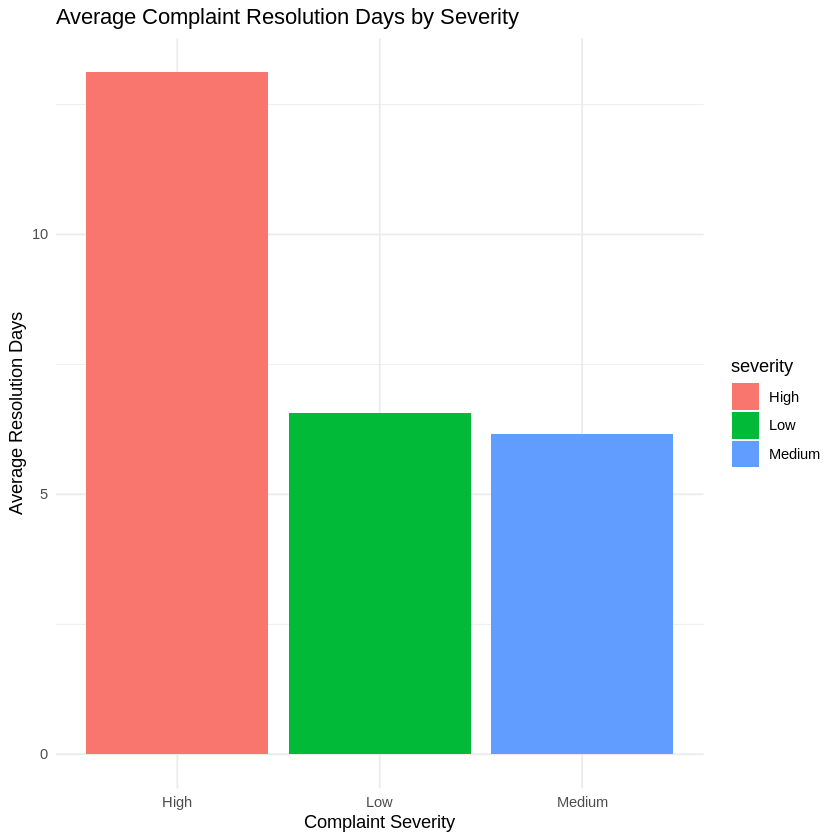

In [4]:
resolution_data <- complaints %>%
  group_by(severity) %>%
  summarise(
    average_resolution =
      mean(resolution_days,
           na.rm = TRUE)
  )

ggplot(
  resolution_data,
  aes(
    x = severity,
    y = average_resolution,
    fill = severity
  )
) +
geom_bar(stat = "identity") +
labs(
  title =
    "Average Complaint Resolution Days by Severity",
  x = "Complaint Severity",
  y = "Average Resolution Days"
) +
theme_minimal()

ANALYTICS 2
Driver Experience vs Driver Rating

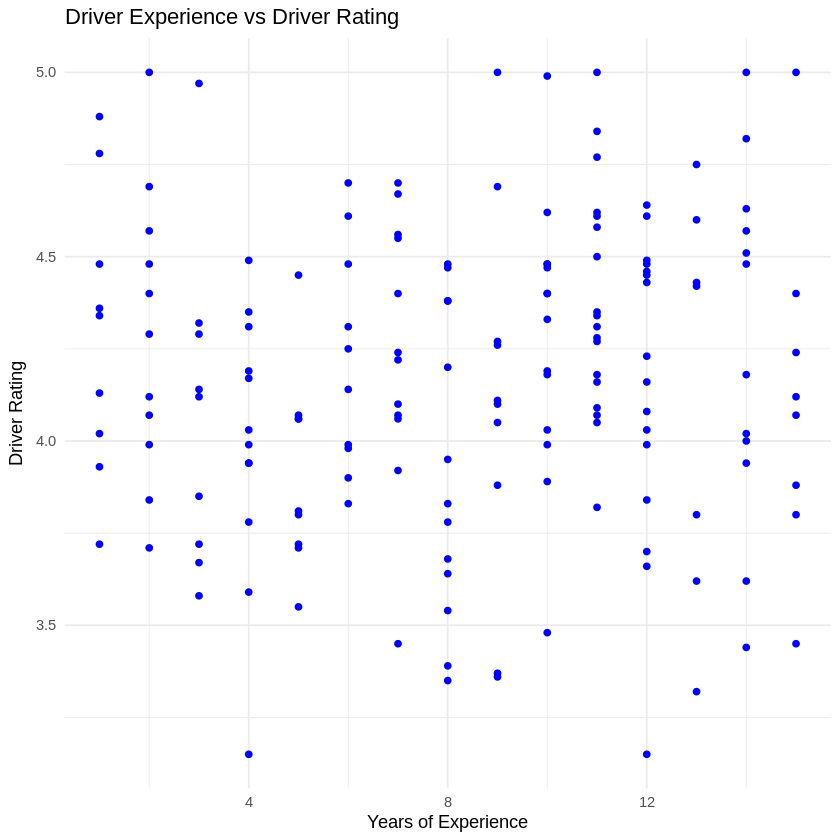

In [6]:
ggplot(
  drivers,
  aes(
    x = years_experience,
    y = driver_rating
  )
) +
geom_point(color = "blue") +
labs(
  title =
    "Driver Experience vs Driver Rating",
  x = "Years of Experience",
  y = "Driver Rating"
) +
theme_minimal()

ANALYTICS 3
Delivery Distance Distribution

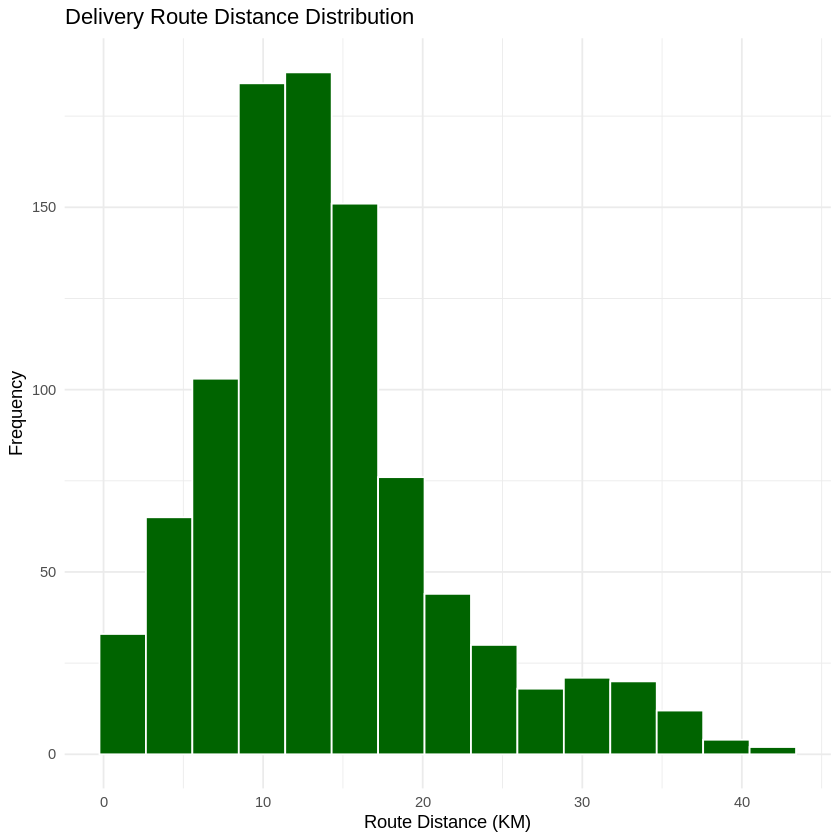

In [8]:
ggplot(
  deliveries,
  aes(
    x = route_distance_km
  )
) +
geom_histogram(
  bins = 15,
  fill = "darkgreen",
  color = "white"
) +
labs(
  title =
    "Delivery Route Distance Distribution",
  x = "Route Distance (KM)",
  y = "Frequency"
) +
theme_minimal()

ANALYTICS 4
Incident Resolution Status Analysis

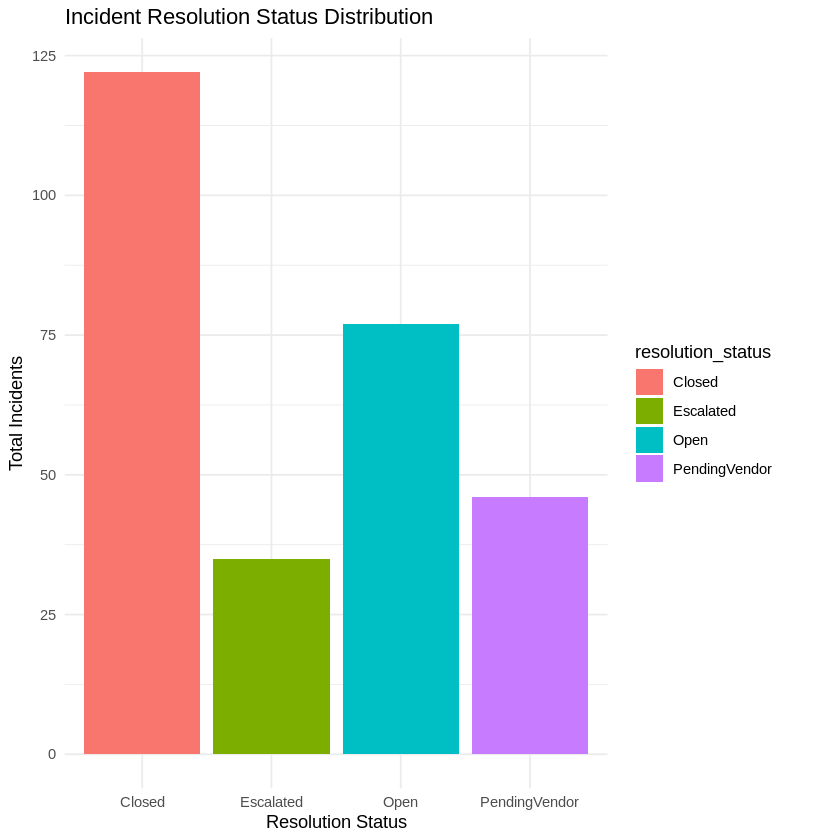

In [9]:
incident_status <- incidents %>%
  group_by(resolution_status) %>%
  summarise(
    total_incidents = n()
  )

ggplot(
  incident_status,
  aes(
    x = resolution_status,
    y = total_incidents,
    fill = resolution_status
  )
) +
geom_bar(stat = "identity") +
labs(
  title =
    "Incident Resolution Status Distribution",
  x = "Resolution Status",
  y = "Total Incidents"
) +
theme_minimal()

ANALYTICS 5
Vehicle Odometer Analysis by Vehicle Type

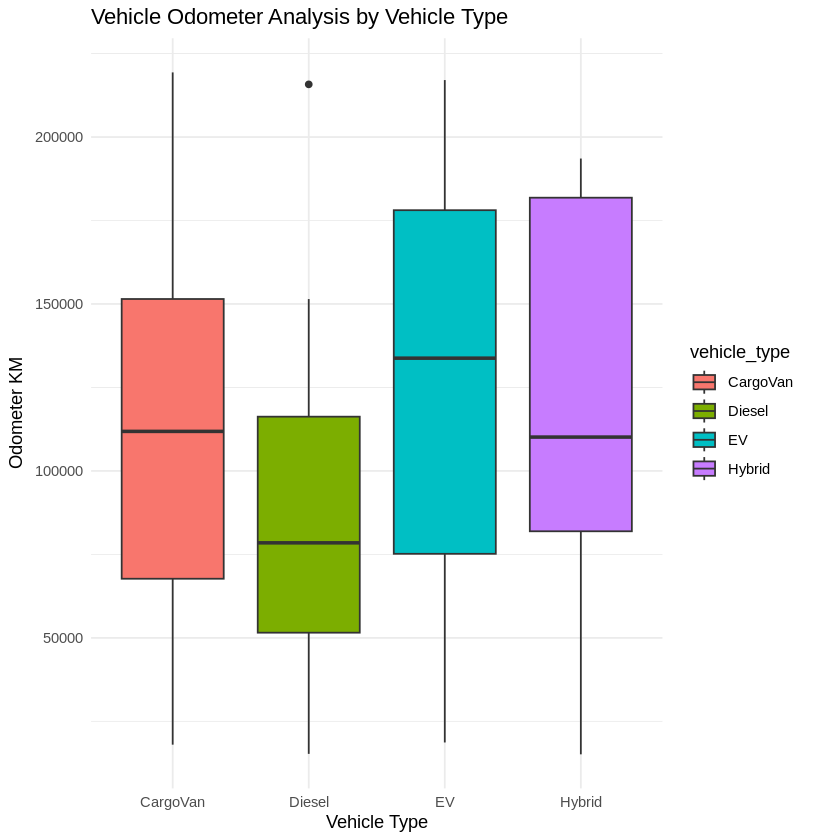

In [10]:
ggplot(
  vehicles,
  aes(
    x = vehicle_type,
    y = odometer_km,
    fill = vehicle_type
  )
) +
geom_boxplot() +
labs(
  title =
    "Vehicle Odometer Analysis by Vehicle Type",
  x = "Vehicle Type",
  y = "Odometer KM"
) +
theme_minimal()

Statistical Correlation Analysis

In [11]:
numeric_data <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    fuel_or_charge_cost
  )

correlation_matrix <- cor(
  numeric_data,
  use = "complete.obs"
)

print(correlation_matrix)

                            route_distance_km manual_route_override_count
route_distance_km                   1.0000000                  0.20229563
manual_route_override_count         0.2022956                  1.00000000
fuel_or_charge_cost                 0.5241945                  0.09868997
                            fuel_or_charge_cost
route_distance_km                    0.52419446
manual_route_override_count          0.09868997
fuel_or_charge_cost                  1.00000000


Correlation Heatmap

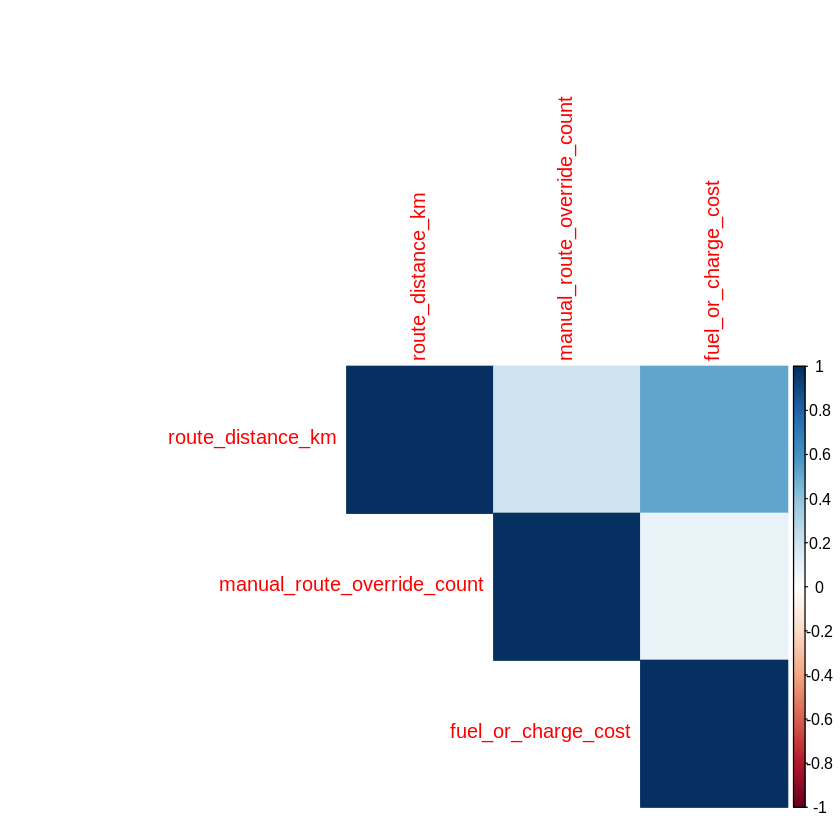

In [13]:
corrplot(
  correlation_matrix,
  method = "color",
  type = "upper"
)